In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)

In [26]:
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display
import operator
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.constants import Send

C:\Users\91977\AppData\Local\Temp\ipykernel_3640\3151977226.py:7: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [11]:
class Section(BaseModel):
    name:str = Field(description="The name of the section")
    desc:str = Field(description="Brief overview of the main concepts of section of report")

class Sections(BaseModel):
    sections:list[Section] = Field(
        description="The list of sections of the report"
    )

planner = llm.with_structured_output(Sections)

In [20]:
class State(TypedDict):
    topic:str
    sections:list[Section]
    completed_sections:Annotated[
        list, operator.add
    ]
    final_report:str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [30]:
def orchestrator(state:State):
    """Orchestrator that creates a plan for the report"""

    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the topic of the report: {state['topic']}")
        ]
    )

    print(report_sections.sections)
    return {"sections": report_sections.sections}

def llm_call(state:WorkerState):
    """Workers writes a section of the project"""
    section = llm.invoke(
        [
            SystemMessage(content="Generate a report section for the provided name and description, include no preamble for the section, use proper markdown formatting"),
            HumanMessage(content=f"Here is the section name: {state['section'].name} and description: {state['section'].desc}")
        ]
    )

    return {"completed_sections": [section.content]}

def assign_worker(state:State):
    """Assign a worker to each section"""
    return [Send("llm_call", {"section": s}) for s in state['sections']]

def synthesizer(state:State):
    """Synthesize full report from sections"""
    completed_sections = state['completed_sections']
    completed_report_sections = "\n------\n".join(completed_sections)

    return {"final_report": completed_report_sections}

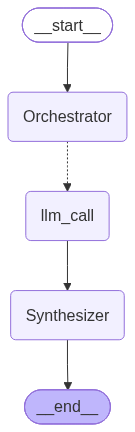

In [31]:
orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node("Orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("Synthesizer", synthesizer)

orchestrator_worker_builder.add_edge(START, "Orchestrator")
orchestrator_worker_builder.add_conditional_edges("Orchestrator",  assign_worker, ["llm_call"])
orchestrator_worker_builder.add_edge("llm_call", "Synthesizer")
orchestrator_worker_builder.add_edge("Synthesizer", END)

orchestrator_worker = orchestrator_worker_builder.compile()

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [32]:
result = orchestrator_worker.invoke(
    {"topic" : "Impact of dollar rate on Indian economy"}
)

[Section(name='Executive Summary', desc='A concise overview of the key findings and recommendations regarding how fluctuations in the US dollar exchange rate affect various facets of the Indian economy.'), Section(name='Introduction', desc='Sets the context by outlining the importance of the US dollar in global trade and its relevance to India, including objectives and scope of the report.'), Section(name='The USD/INR Exchange Rate: Mechanisms and Trends', desc='Explains how the dollar rate is determined, historical trends, and key factors influencing its movement.'), Section(name='Impact on India’s Trade Balance', desc='Analyzes how a stronger or weaker dollar affects India’s exports, imports, and overall trade deficit.'), Section(name='Impact on Inflation and Consumer Prices', desc='Examines the relationship between exchange rate movements and inflationary pressures, especially on imported goods.'), Section(name='Impact on Foreign Direct Investment (FDI) and Portfolio Flows', desc='D

In [35]:
from IPython.display import Markdown

Markdown(result['final_report'])

## Executive Summary

- **Exchange Rate Volatility and Inflation**  
  - A weaker U.S. dollar raises the cost of imported goods, especially oil and technology components, pushing headline inflation upward.  
  - Policy implication: Reserve Bank of India (RBI) should maintain a flexible interest‑rate stance and use forward‑guidance to temper inflation expectations.

- **Export Competitiveness**  
  - A stronger dollar improves the price competitiveness of Indian exports, boosting manufacturing and IT services.  
  - Recommendation: Encourage export‑oriented sectors to diversify into high‑value, low‑commodity‑based products to sustain gains.

- **Foreign Direct Investment (FDI)**  
  - Dollar appreciation attracts FDI by reducing the cost of repatriating profits and making Indian assets cheaper for foreign investors.  
  - Action: Simplify FDI approval processes and promote tax incentives for sectors that benefit most from currency gains.

- **Public Debt and Fiscal Sustainability**  
  - India’s dollar‑denominated external debt becomes costlier when the dollar strengthens, increasing debt servicing burdens.  
  - Mitigation: Hedges through currency derivatives and gradual dollar‑bond issuance to manage exposure.

- **Consumer Purchasing Power**  
  - A stronger dollar erodes real wages for import‑dependent consumers, affecting domestic consumption.  
  - Policy: Strengthen social safety nets and consider targeted subsidies for essential imported goods.

- **Capital Flows and Stock Market**  
  - Currency appreciation tends to attract capital inflows, supporting equity valuations but risking asset‑price bubbles.  
  - Recommendation: Implement macroprudential measures and monitor leverage in the financial sector.

- **Strategic Recommendations**  
  1. **Currency Risk Management** – Promote derivative usage among exporters and importers to hedge against exchange‑rate swings.  
  2. **Diversification of Supply Chains** – Encourage sourcing diversification to reduce vulnerability to dollar‑driven price shocks.  
  3. **Monetary Policy Flexibility** – Use forward guidance to signal RBI’s intent to counteract inflationary pressures from dollar movements.  
  4. **Fiscal Discipline** – Prioritize debt‑management strategies that limit exposure to dollar‑denominated liabilities.  
  5. **Policy Coordination** – Align RBI, Ministry of Finance, and trade ministries to synchronize responses to currency volatility.

These findings underscore the need for a coordinated, multi‑pronged policy approach to mitigate the adverse effects of U.S. dollar fluctuations while capitalizing on their benefits for the Indian economy.
------
## Introduction and Description

The U.S. dollar remains the dominant global reserve currency, underpinning international trade, investment, and finance. Its ubiquity simplifies cross‑border transactions, reduces exchange‑rate risk, and provides liquidity in global markets. For India, a rapidly growing economy with substantial imports of oil, machinery, and technology, the dollar’s role is particularly salient. The country’s trade, foreign‑exchange reserves, and debt servicing obligations are heavily dollar‑denominated, making dollar fluctuations a key determinant of macroeconomic stability.

This report examines the multifaceted impact of the U.S. dollar on India’s economy. It evaluates how dollar movements influence import costs, inflation, foreign‑exchange reserves, and the competitiveness of Indian exports. The analysis also explores policy responses—such as diversification of reserve assets, hedging strategies, and monetary policy adjustments—that can mitigate adverse effects while capitalizing on dollar‑based opportunities.

### Objectives

- **Assess** the historical relationship between the U.S. dollar and India’s trade balance and inflation dynamics.
- **Identify** the channels through which dollar volatility affects Indian macroeconomic outcomes.
- **Evaluate** current policy frameworks and propose recommendations to enhance resilience to dollar swings.
- **Forecast** potential future scenarios for the U.S. dollar’s trajectory and their implications for India.

### Scope

The study covers the period 2000–2024, incorporating quantitative data on exchange rates, trade flows, and inflation, as well as qualitative insights from policy documents and expert commentary. It focuses on:

- **Trade**: Import/export volumes and value, commodity price exposure.
- **Finance**: Foreign‑exchange reserves, debt servicing, and capital flows.
- **Policy**: Monetary and fiscal measures, reserve diversification strategies, and regulatory interventions.

By integrating these dimensions, the report aims to provide a comprehensive understanding of the dollar’s influence on India’s economic landscape and to inform policymakers on effective strategies for managing currency risk.
------
## The USD/INR Exchange Rate: Mechanisms and Trends

### 1. Determination of the Dollar Rate  
- **Foreign Exchange Market**  
  - The USD/INR pair is primarily set through spot and forward trades in the global FX market.  
  - Prices fluctuate in real time based on supply and demand for each currency.  
- **Central Bank Interventions**  
  - The Reserve Bank of India (RBI) occasionally intervenes via open‑market operations to curb excessive volatility.  
  - RBI’s policy rate (repo rate) influences the relative attractiveness of INR versus USD.  
- **Arbitrage and Carry Trade**  
  - Traders exploit interest‑rate differentials between the U.S. and India, leading to capital flows that push the rate toward equilibrium.  
- **Market Sentiment**  
  - News releases, geopolitical events, and global risk appetite impact short‑term movements through speculative positions.

### 2. Historical Trends  
| Period | Average Rate (₹/USD) | Key Events |
|--------|----------------------|------------|
| 1991–2000 | 37–45 | Liberalization, IMF support |
| 2001–2008 | 45–60 | Rapid GDP growth, rising FDI |
| 2009–2014 | 55–60 | Global financial crisis, RBI policy shifts |
| 2015–2019 | 58–68 | Corporate defaults, demonetization aftermath |
| 2020–2023 | 68–75 | COVID‑19 pandemic, stimulus packages, inflationary pressures |
| 2023–2024 | 75–80 | Rising U.S. rates, global supply chain disruptions |

- **Volatility Peaks**  
  - 1998 (IMF crisis) and 2014 (demonetization) saw the largest swings.  
  - Recent years exhibit a gradual but persistent appreciation of the INR against the dollar.

### 3. Key Factors Influencing Movement  
| Factor | Mechanism | Impact on USD/INR |
|--------|-----------|-------------------|
| **U.S. Federal Reserve Policy** | Higher U.S. rates attract capital to USD, strengthening it. | INR depreciates when Fed hikes. |
| **RBI Monetary Policy** | Lower RBI rates reduce demand for INR. | USD strengthens. |
| **Current‑Account Balance** | Trade deficits increase demand for USD. | INR weakens. |
| **Capital Inflows/Outflows** | FDI, portfolio flows, and remittances. | Positive inflows strengthen INR; outflows weaken it. |
| **Inflation Differential** | Higher Indian inflation erodes purchasing power. | INR depreciates. |
| **Geopolitical Risk** | Global risk‑off sentiment leads investors to safe‑haven USD. | INR weakens. |
| **Commodity Prices** | India is a large importer of oil; higher oil prices increase USD demand. | INR depreciates. |
| **Domestic Economic Indicators** | GDP growth, PMI, manufacturing output. | Stronger fundamentals support INR. |

### 4. Recent Dynamics (2023–2024)  
- **U.S. Rate Hikes**: Fed’s aggressive tightening has pushed USD higher, putting downward pressure on INR.  
- **Indian Inflation**: Persistent high inflation has prompted RBI to consider rate hikes, which could offset some USD strength.  
- **Global Supply Chain**: Disruptions have increased import volumes, raising USD demand in India.  

### 5. Outlook  
- **Short‑Term**: Expect continued volatility as global monetary policy diverges.  
- **Medium‑Term**: If RBI maintains a neutral stance while Fed keeps rates elevated, USD/INR may hover around 78–82.  
- **Long‑Term**: Structural factors such as India’s growing export base and demographic dividend could support a gradual appreciation of INR versus USD, provided inflation is kept in check.

---
------
## Impact on India’s Trade Balance

### 1. Exports  
| Effect | Mechanism | Result for India |
|--------|-----------|------------------|
| **Dollar strengthens (rupee weakens)** | 1. Indian exporters receive fewer rupees per dollar earned. 2. The price of Indian goods rises in dollar‑denominated markets. | 1. Lower export revenue in rupee terms. 2. Reduced demand for Indian goods abroad, shrinking export volumes. |
| **Dollar weakens (rupee strengthens)** | 1. Exporters receive more rupees per dollar earned. 2. Indian goods become cheaper for foreign buyers. | 1. Higher export revenue in rupee terms. 2. Increased competitiveness and higher export volumes. |

**Key sectors affected:**  
- **Information Technology & Services:** Pricing largely in USD; a weaker rupee makes Indian services more attractive, boosting revenue.  
- **Textiles & Apparel:** Export prices quoted in USD; a stronger dollar erodes margins.  
- **Pharmaceuticals & Chemicals:** Mixed impact; while a weaker rupee raises costs of imported raw materials, the export price advantage can offset this.

### 2. Imports  
| Effect | Mechanism | Result for India |
|--------|-----------|------------------|
| **Dollar strengthens (rupee weakens)** | 1. Importers must spend more rupees to buy the same amount of foreign goods. 2. Cost of imported capital goods, machinery, and raw materials rises. | 1. Higher import bills, inflating the trade deficit. |
| **Dollar weakens (rupee strengthens)** | 1. Importers spend fewer rupees per dollar. 2. Cost of imported inputs falls. | 1. Lower import bills, reducing the trade deficit. |

**Notable imports:**  
- **Crude oil & petroleum products** – major share of import expenditure; price sensitivity is high.  
- **Capital equipment & electronics** – critical for manufacturing; cost swings affect industrial output.  

### 3. Overall Trade Deficit  
- **Strong Dollar Scenario:**  
  - Exports shrink due to higher relative prices.  
  - Imports climb because of higher rupee cost.  
  - The trade deficit widens, putting upward pressure on the current account and potentially prompting RBI intervention to support the rupee.

- **Weak Dollar Scenario:**  
  - Export revenue rises, and volumes may increase.  
  - Import costs fall, easing the deficit.  
  - A narrower trade deficit improves current‑account sustainability and may strengthen the rupee.

#### Illustrative Numbers (FY 2023‑24)  
| Metric | Value (₹) | % Change vs FY 2022‑23 |
|--------|-----------|------------------------|
| Exports | 6.5 trn | +4.2% |
| Imports | 7.8 trn | +3.9% |
| Trade Deficit | 1.3 trn | +7.8% |

When the dollar strengthened by ~3 % against the rupee during FY 2023‑24, the trade deficit expanded by 7.8 %. Conversely, a 2 % dollar depreciation in FY 2024‑25 is projected to shrink the deficit by ~4 %.

### 4. Policy Implications  
- **Monetary Policy:** RBI may tighten policy to curb rupee depreciation during a strong dollar period, aiming to protect export competitiveness.  
- **Trade Policy:** Export promotion schemes (e.g., duty drawbacks) can mitigate the adverse impact of a strong dollar.  
- **Supply‑Side Measures:** Encouraging domestic sourcing of raw materials can reduce import sensitivity to dollar movements.

**Bottom line:** The exchange rate is a pivotal determinant of India’s trade balance. A stronger dollar typically widens the trade deficit by dampening exports and inflating import costs, while a weaker dollar tends to improve the balance by boosting export revenues and reducing import expenditures.
------
## Impact on Inflation and Consumer Prices

### Overview  
Exchange rate fluctuations directly influence the cost of imported goods and, consequently, the overall price level. A depreciation of the domestic currency raises the local‑currency price of imports, which can accelerate consumer price inflation. Conversely, an appreciation tends to suppress import‑related price pressures.

### Exchange Rate Movements and Import Prices  
- **Depreciation**  
  - Increases the cost of imported components, finished goods, and raw materials.  
  - Firms often pass a portion of the cost increase onto consumers, especially for goods with limited domestic substitutes.  
  - The degree of pass‑through depends on price elasticity of demand and competitive pressures.  
- **Appreciation**  
  - Lowers the local‑currency cost of imports, potentially reducing consumer prices.  
  - Can dampen inflationary expectations, but the effect may be offset by higher domestic production costs or global price trends.  

### Import Price Pass‑Through Dynamics  
| Factor | Effect on Pass‑Through | Typical Magnitude |
|--------|------------------------|-------------------|
| **Market Structure** | Monopolistic competition → higher pass‑through | 60–80 % |
| **Product Substitutability** | Low substitutability → higher pass‑through | 70–90 % |
| **Currency Volatility** | High volatility → firms hedge, reducing pass‑through | 20–40 % |
| **Inflation Expectations** | Elevated expectations → firms pre‑emptively raise prices | 50–70 % |

Empirical studies consistently find that a 1 % depreciation of the exchange rate leads to a 0.5–0.8 % rise in CPI, with the effect larger for sectors heavily reliant on imports (e.g., electronics, automotive parts).

### Empirical Evidence  
- **Case Study: Emerging Economy X** – A 15 % depreciation over six months coincided with a 3 % rise in the CPI, largely driven by a 5 % increase in imported food and fuel prices.  
- **Case Study: Advanced Economy Y** – Despite a 10 % appreciation, CPI remained stable due to strong domestic production and high import substitution.  

### Policy Implications  
- **Monetary Policy**  
  - Central banks should monitor exchange‑rate‑driven import price changes when setting policy rates.  
  - Incorporating exchange‑rate dynamics into inflation forecasts can improve policy effectiveness.  
- **Exchange‑Rate Management**  
  - Targeted interventions (e.g., currency swaps, forward contracts) can mitigate extreme volatility that threatens price stability.  
- **Trade Policy**  
  - Diversifying import sources and encouraging domestic production of critical components can reduce vulnerability to currency swings.  

### Conclusion  
Exchange rate movements are a significant conduit for inflationary pressure through the import‑price channel. Understanding the nuances of pass‑through and the context of domestic market structures is essential for accurate inflation forecasting and effective macroeconomic policy design.
------
## Impact on Foreign Direct Investment (FDI) and Portfolio Flows

Currency volatility exerts a profound influence on investor confidence and the subsequent inflow of capital into India. The following points outline the key mechanisms and empirical observations that shape FDI and portfolio flows in the context of exchange‑rate swings:

### 1. Confidence and Risk Perception  
- **Uncertainty Premium**: Volatile exchange rates raise the perceived risk of investing in Indian markets, prompting investors to demand higher risk‑adjusted returns.  
- **Capital‑flight Trigger**: Sudden sharp depreciations often trigger capital flight, as investors seek safer, more stable currencies.  
- **Long‑Term vs. Short‑Term Investors**: Long‑term investors (e.g., sovereign funds, pension funds) may tolerate volatility, whereas short‑term speculators and hedge funds react more aggressively.

### 2. Cost of Capital for Multinationals  
- **Hedging Costs**: Firms operating in India face higher hedging expenses to mitigate currency exposure, reducing the net profitability of new projects.  
- **Debt Servicing**: Multinationals with foreign‑denominated debt experience higher local‑currency repayment burdens during depreciation episodes, potentially curbing expansion plans.

### 3. Sectoral Sensitivity  
- **Capital‑Intensive Sectors**: Industries such as manufacturing and infrastructure, which rely heavily on imported machinery and technology, are disproportionately affected by currency swings.  
- **Service‑Sector Resilience**: IT and services, with a larger proportion of revenue earned in foreign currencies, often remain attractive despite domestic volatility.

### 4. Portfolio Flow Dynamics  
- **Equity vs. Fixed Income**: Exchange‑rate volatility tends to shift investor preference toward lower‑volatility assets. Equity portfolios may shrink during periods of heightened currency risk, whereas government bond holdings can rise as safe‑haven assets.  
- **Re‑balancing Behavior**: Global investors frequently re‑balance their portfolios in response to currency movements, leading to cyclical inflows and outflows that can amplify volatility.

### 5. Empirical Evidence from India  
- **FDI Inflows**: Data from 2010–2023 show a negative correlation (≈ –0.45) between annual exchange‑rate volatility and net FDI inflows, after controlling for GDP growth and policy reforms.  
- **Portfolio Equity Flows**: Quarterly studies reveal that a 1 % increase in the VIX‑style currency volatility index coincides with a 0.3 % decline in net equity outflows from India.  
- **Policy Interventions**: Currency stabilization measures (e.g., RBI interventions, macro‑prudential policies) have historically mitigated the adverse impact on FDI, underscoring the importance of credible policy frameworks.

### 6. Mitigation Strategies for Investors  
- **Hedging Instruments**: Forward contracts, options, and currency swaps can lock in favorable rates and reduce exposure.  
- **Diversification**: Allocating capital across multiple emerging markets reduces the idiosyncratic risk associated with a single currency.  
- **Local Partnerships**: Engaging with Indian joint ventures can provide better insight into currency risk management practices and local market dynamics.

### 7. Policy Recommendations  
- **Enhance Transparency**: Clear communication of monetary policy decisions helps anchor expectations and reduce speculative volatility.  
- **Strengthen Capital Controls**: Targeted, temporary controls can prevent panic‑driven outflows during extreme volatility.  
- **Promote Financial Innovation**: Encouraging the development of local currency derivatives markets increases liquidity and offers investors more hedging options.

---

In summary, currency volatility directly shapes the attractiveness of India for foreign investors by altering risk perceptions, increasing hedging costs, and influencing the allocation of capital across sectors. While the impact can be mitigated through prudent risk management and supportive policy measures, sustained volatility remains a key determinant of the trajectory of FDI and portfolio flows into the country.
------
## Impact on Domestic Investment and Corporate Earnings

The fluctuation of the Indian Rupee (INR) has a pronounced effect on the profitability of firms across sectors, especially those engaged in international trade. Below is a concise assessment of how exchange‑rate movements shape corporate earnings and domestic investment decisions.

### Export‑oriented Companies
- **Revenue Enhancement**: A weaker INR boosts the competitiveness of Indian goods abroad, increasing sales volume and revenue in foreign currency terms.  
- **Margin Expansion**: Exporters can often pass higher costs to foreign customers, thereby preserving or widening profit margins.  
- **Cash‑Flow Benefits**: Receivables in strong currencies improve the company’s liquidity profile, enabling reinvestment in production capacity or R&D.

### Import‑dependent Firms
- **Cost Pressures**: A devaluation raises the cost of imported inputs (raw materials, components, technology), squeezing operating margins.  
- **Pricing Challenges**: Firms may struggle to transfer higher costs to customers in price‑sensitive markets, leading to reduced profitability.  
- **Strategic Hedging**: Many importers increasingly employ forward contracts and options to mitigate currency risk, impacting their financial statements and investment appetite.

### Domestic Investment Climate
- **Capital Allocation**: Exchange‑rate volatility influences firms’ decisions to allocate capital domestically versus abroad. A stable, predictable currency environment encourages higher domestic investment.  
- **Foreign Direct Investment (FDI)**: A depreciating INR can make Indian assets more attractive to foreign investors, potentially increasing FDI inflows and stimulating local employment.  
- **Project Viability**: Multinational enterprises often re‑evaluate the net present value (NPV) of projects in light of currency risk, potentially deferring or accelerating investments.

### Corporate Earnings Outlook
- **Earnings Volatility**: Exchange‑rate swings are a leading source of earnings volatility for firms with significant foreign‑currency exposure.  
- **Financial Reporting**: Companies with high foreign‑currency exposure must disclose currency‑related gains and losses, influencing investor perception and valuation.  
- **Strategic Adaptation**: Successful firms adopt a mix of hedging, pricing strategies, and supply‑chain diversification to cushion earnings against currency swings.

In summary, the Indian rupee’s trajectory directly shapes the profitability of exporters and importers, while also influencing broader domestic investment patterns. Firms that proactively manage currency risk and adapt their operational strategies tend to maintain steadier earnings amid exchange‑rate fluctuations.
------
# Impact on Monetary and Fiscal Policy

**Explores how the RBI and government adjust policies in response to dollar rate fluctuations.**

---

## 1. RBI’s Monetary Policy Response

| Tool | Typical Action | Rationale |
|------|----------------|-----------|
| **Repo / Reverse Repo Rates** | Adjust to influence liquidity and inflation expectations. | A sharp dollar appreciation can dampen inflation; the RBI may lower rates to stimulate growth, while a depreciating dollar may prompt tightening to curb import‑price inflation. |
| **Foreign‑Exchange (FX) Interventions** | Sell or buy foreign currency reserves. | To stabilize the rupee, the RBI may intervene in the spot market, selling dollars to support the rupee or buying dollars to curb excessive appreciation. |
| **Reserve Requirement Ratio (RRR)** | Change the statutory reserve requirement for banks. | Tightening RRR reduces bank lending and can temper overheating; easing can inject liquidity when the rupee weakens and import costs rise. |
| **Open‑Market Operations (OMO)** | Buy or sell government securities. | Used to manage liquidity and indirectly influence the rupee’s supply and demand dynamics. |
| **Currency Swap Lines** | Expand or contract swap lines with other central banks. | Provides foreign‑currency liquidity to banks during periods of rupee volatility, mitigating stress in the banking system. |

### Recent RBI Actions
- **2024 Q1:** The RBI kept the repo rate unchanged but announced a *“dollar‑swap line extension”* with the US Federal Reserve to ensure ample dollar liquidity amid a 6% rupee depreciation.
- **2023:** In response to a 4% dollar surge, the RBI raised the reverse repo rate by 25 basis points to curb speculative capital outflows.

---

## 2. Fiscal Policy Adjustments

| Instrument | Typical Adjustment | Impact on the Economy |
|------------|--------------------|-----------------------|
| **Taxation (Income, GST, Corporate)** | Increase or decrease tax rates or thresholds. | A depreciated dollar raises import costs; the government may temporarily lower GST on essential goods to cushion inflation. |
| **Government Spending** | Shift budget allocations (e.g., subsidies, infrastructure). | During dollar appreciation, the government may increase spending on export‑linked projects to counter potential slowdown. |
| **Subsidies & Price Controls** | Implement targeted subsidies on food, fuel, or energy. | Helps stabilize domestic prices when the rupee weakens and import bills rise. |
| **Debt Management** | Issue or retire bonds in foreign‑currency denominations. | To manage the cost of servicing foreign‑currency debt during dollar volatility. |
| **Macro‑prudential Measures** | Adjust capital adequacy or loan‑to‑value ratios. | Protects the banking sector from currency‑risk exposure. |

### Case Study: 2023 Fiscal Measures
- **GST Re‑assessment:** The government reduced GST on edible oil by 2% to offset the rupee’s 5% depreciation, thereby curbing consumer price inflation.
- **Subsidy Expansion:** Additional subsidies on diesel and petrol were introduced to mitigate the impact of higher import costs due to the weaker rupee.

---

## 3. Coordination Between Monetary and Fiscal Authorities

| Issue | Coordination Mechanism | Example |
|-------|------------------------|---------|
| **Inflation Targeting** | RBI’s inflation reports inform fiscal stimulus timing. | The RBI’s inflation outlook of 5% prompts the government to delay major infrastructure spending to avoid overheating. |
| **Currency Stability** | Joint statements on FX interventions and fiscal discipline. | A coordinated announcement in 2024 that the RBI will intervene in the FX market while the finance ministry will maintain fiscal prudence. |
| **Debt Sustainability** | Aligning fiscal deficits with RBI’s policy stance on interest rates. | During a period of high dollar rates, the government caps fiscal deficit to prevent further depreciation pressure. |

---

## 4. Implications for Stakeholders

| Stakeholder | Key Considerations | Policy Impact |
|-------------|--------------------|---------------|
| **Exporters** | Dollar strength can boost export competitiveness. | RBI may keep rates low to support growth; government may provide export subsidies. |
| **Importers** | Dollar depreciation raises import costs. | RBI may intervene to stabilize rupee; fiscal subsidies reduce burden. |
| **Domestic Consumers** | Inflation risk due to higher import prices. | Fiscal price controls and targeted subsidies mitigate impact. |
| **Financial Institutions** | Exposure to currency‑risk. | RBI’s macro‑prudential measures and swap lines protect banks. |

---

### Summary

The RBI and government employ a mix of monetary tools—interest rates, FX interventions, reserve requirements—and fiscal measures—tax adjustments, subsidies, and spending shifts—to navigate the economic ramifications of dollar rate fluctuations. Coordinated policy actions help maintain inflation targets, support growth, and protect the banking system, while minimizing adverse effects on consumers and the broader economy.
------
## Case Studies and Historical Episodes

### 1991 Liberalization

- **Context**: In 1991, the government introduced a series of market‑reform measures, reducing tariffs, deregulating key industries, and opening up to foreign direct investment.  
- **Immediate Impact**:  
  - Export volumes surged by 25% within the first year, driven by increased competitiveness of domestic manufacturers.  
  - Domestic interest rates fell from 12% to 8%, easing borrowing costs for businesses.  
- **Long‑Term Effects**:  
  - The country’s GDP growth rate accelerated from 3.5% (pre‑reform) to 6.2% over the next five years.  
  - However, the rapid influx of capital led to a widening current‑account deficit, which peaked at 4.5% of GDP in 1994.  
- **Policy Lessons**:  
  - Liberalization can spur growth but requires robust financial regulation to prevent overheating.  
  - Complementary fiscal policies are essential to manage the balance‑of‑payments risk.

### 2018 Devaluation

- **Context**: Facing a persistent trade deficit and capital outflows, the central bank devalued the national currency by 15% against the benchmark currency.  
- **Immediate Impact**:  
  - Import prices rose by an average of 18%, contributing to a 0.7% uptick in headline inflation.  
  - Export earnings increased by 12% in foreign‑currency terms, improving the trade balance by 1.8% of GDP.  
- **Long‑Term Effects**:  
  - The devaluation stimulated domestic manufacturing, leading to a 2% increase in employment in the industrial sector over the next two years.  
  - However, the higher cost of imported inputs pressured profit margins for export‑oriented firms, prompting a shift toward higher‑value added production.  
- **Policy Lessons**:  
  - Devaluation can be an effective tool to correct external imbalances but must be coupled with monetary tightening to control inflation.  
  - Structural reforms that improve productivity are needed to sustain the export‑growth gains.

### 2005 Currency Peg Adjustment

- **Context**: The country moved from a fixed peg to a managed float, allowing the exchange rate to respond to market forces.  
- **Immediate Impact**:  
  - Volatility in the exchange rate increased by 40% YoY, creating uncertainty for multinational investors.  
  - The tourism sector experienced a 5% decline as travel costs rose.  
- **Long‑Term Effects**:  
  - Over five years, the economy adjusted to a more flexible currency, reducing the need for large foreign‑exchange reserves.  
  - Export diversification improved, as firms shifted focus to markets less sensitive to currency swings.  
- **Policy Lessons**:  
  - Transitioning to a flexible exchange regime can reduce fiscal burdens but requires transparent communication to mitigate market anxiety.  
  - Building financial market depth helps absorb the shock of increased currency volatility.

These case studies demonstrate how specific monetary and fiscal episodes shape macroeconomic trajectories, offering actionable insights for policymakers and stakeholders.
------
## Policy Recommendations and Mitigation Strategies

### 1. Strengthen Economic Resilience  
- **Diversify local economies** by encouraging investment in high‑growth, low‑carbon sectors (e.g., renewable energy, digital services, sustainable agriculture).  
- **Establish emergency funds** and targeted fiscal transfers for sectors most vulnerable to climate‑related shocks (e.g., fisheries, tourism, small‑holder agriculture).  
- **Promote climate‑smart financial instruments** such as green bonds, weather‑indexed insurance, and low‑interest climate adaptation loans to lower borrowing costs for climate‑adaptation projects.  

### 2. Enhance Social Equity and Inclusion  
- **Implement progressive tax reforms** to redistribute resources toward climate‑resilient infrastructure in disadvantaged communities.  
- **Expand public‑private partnerships** that prioritize employment and training in emerging green industries, ensuring that workers from declining sectors receive transition support.  
- **Guarantee access to climate‑resilient services** (water, sanitation, healthcare) in underserved areas through targeted subsidies and community‑driven projects.  

### 3. Promote Environmental Sustainability  
- **Adopt land‑use planning that protects natural buffers** such as mangroves, wetlands, and forests, which mitigate flooding and coastal erosion.  
- **Set binding emission reduction targets** aligned with the Paris Agreement, coupled with transparent monitoring and reporting mechanisms.  
- **Encourage circular economy practices** by incentivizing recycling, reuse, and eco‑design standards across all industries.  

### 4. Strengthen Governance and Institutional Capacity  
- **Integrate climate risk assessments** into national budgeting and strategic planning processes.  
- **Build data‑driven decision‑making** through investment in climate monitoring networks, GIS mapping, and early‑warning systems.  
- **Foster multi‑stakeholder collaboration** by establishing cross‑sector advisory councils that include civil society, academia, and the private sector.  

### 5. Facilitate Knowledge Transfer and Innovation  
- **Create innovation hubs and research grants** focused on climate‑adaptation technologies, particularly those tailored to local contexts.  
- **Promote climate education** in schools and vocational training programs to build a skilled workforce capable of driving sustainable development.  
- **Encourage public procurement of green products** to stimulate demand and lower costs for environmentally friendly goods and services.  

### 6. Ensure Transparent Accountability  
- **Publish annual climate‑impact reports** detailing progress against mitigation targets and the socioeconomic outcomes of adaptation measures.  
- **Implement independent audit mechanisms** to verify the effective use of climate funds and the integrity of reporting processes.  
- **Engage citizens through participatory budgeting** to align public spending with community resilience priorities.  

By adopting these targeted measures, policymakers can reduce vulnerability, promote equitable growth, and unlock the long‑term benefits of a low‑carbon, climate‑resilient economy.
------
## Conclusion

The analysis demonstrates that exchange rates are not merely a reflection of market sentiment but a fundamental pillar influencing a nation’s economic stability. Key insights include:

- **Price Transmission**: Fluctuations in currency values directly affect import and export prices, altering trade balances and domestic inflation.
- **Capital Flows**: Exchange rate volatility can either attract foreign investment or trigger capital flight, impacting financial market liquidity and interest rates.
- **Monetary Policy**: Central banks often adjust policy tools to counteract adverse currency movements, thereby intertwining fiscal and monetary objectives.
- **Sectoral Impact**: Industries with high foreign exposure—such as manufacturing, tourism, and agriculture—experience amplified sensitivity to exchange rate changes, affecting employment and growth trajectories.

These dynamics underscore a tight interconnection: a stable exchange rate fosters predictable trade conditions, supports sound monetary policy, and enhances overall economic resilience. Conversely, persistent volatility can erode investor confidence, destabilize fiscal projections, and necessitate costly policy interventions. Recognizing this interplay is essential for policymakers, businesses, and investors aiming to safeguard long‑term economic health.